In [1]:
# Install windrose (for wind rose plots)
!pip install windrose

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from windrose import WindroseAxes

print("Libraries loaded!")


Libraries loaded!


In [23]:
# Upload your CSV and change this path
file_path = '/content/togo-dapaong_qc.csv'

# Load CSV
df = pd.read_csv(file_path)

# Convert timestamp to datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

print("Data loaded. First 5 rows:")
df.head()


Data loaded. First 5 rows:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [24]:
# Numeric summary
print("Summary Statistics:")
display(df.describe())

# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

print("Columns with missing values:")
display(missing[missing > 0])

print("Columns with >5% missing:")
display(missing_percent[missing_percent > 5])


Summary Statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


Columns with missing values:


,0
Comments,525600


Columns with >5% missing:


,0
Comments,100.0


In [25]:
cols = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

# Flag rows with Z-score > 3
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outlier rows: {outliers.sum()}")

# View outliers
df_outliers = df[outliers]
display(df_outliers)


Number of outlier rows: 9251


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-10-28 11:06:00,1139.0,805.1,466.1,1172.0,1154.0,29.8,70.8,2.2,2.6,0.4,298.6,13.4,977,0,0.0,44.7,50.2,NaN
2021-10-28 18:11:00,-1.2,0.0,0.0,0.0,0.0,29.7,63.5,6.6,9.7,1.6,122.1,14.3,976,0,0.0,30.0,29.5,NaN
2021-10-28 18:12:00,-1.0,0.0,0.0,0.0,0.0,29.3,62.4,6.9,8.9,1.2,128.7,10.8,976,0,0.0,29.9,29.5,NaN
2021-10-28 18:14:00,-0.8,0.0,0.0,0.0,0.0,28.6,63.7,7.1,8.9,1.1,127.9,14.4,976,0,0.0,29.5,29.2,NaN
2021-10-28 18:21:00,-1.3,0.0,0.0,0.0,0.0,27.7,64.5,6.1,8.9,1.3,123.2,14.4,977,0,0.0,28.4,28.2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-14 11:54:00,709.5,63.7,629.8,703.1,694.9,30.2,66.6,3.5,4.4,0.8,167.0,15.2,977,0,0.0,46.8,51.6,NaN
2022-10-14 11:55:00,677.8,40.6,621.7,670.1,662.2,30.2,66.7,2.8,3.6,0.6,175.1,19.7,977,0,0.0,46.8,51.6,NaN
2022-10-14 11:56:00,659.5,29.7,614.9,651.0,643.4,30.3,66.1,4.1,4.9,0.5,174.0,11.5,977,0,0.0,46.8,51.6,NaN


In [26]:
# Make a copy to clean
df_clean = df.copy()

# Replace outliers with median
for col in cols:
    median = df_clean[col].median()
    df_clean[col] = df_clean[col].mask(z_scores[:, cols.index(col)] > 3, median)

# Fill missing values with median
for col in cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Data cleaned successfully.")
df_clean.describe()


Data cleaned successfully.


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,229.831936,149.368966,112.408673,225.827121,219.104385,27.751788,55.013160,2.330341,3.173601,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,321.643747,248.554496,151.292938,316.959049,307.362214,4.758023,28.778732,1.388202,1.770451,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,441.100000,241.300000,210.200000,421.900000,410.100000,31.100000,80.800000,3.200000,4.300000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1198.000000,904.100000,586.000000,1178.000000,1143.000000,41.400000,99.800000,6.700000,8.800000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [27]:
clean_file = '/content/benin_clean.csv'
df_clean.to_csv(clean_file, index=False)
print(f"Cleaned CSV saved to {clean_file}")


Cleaned CSV saved to /content/benin_clean.csv


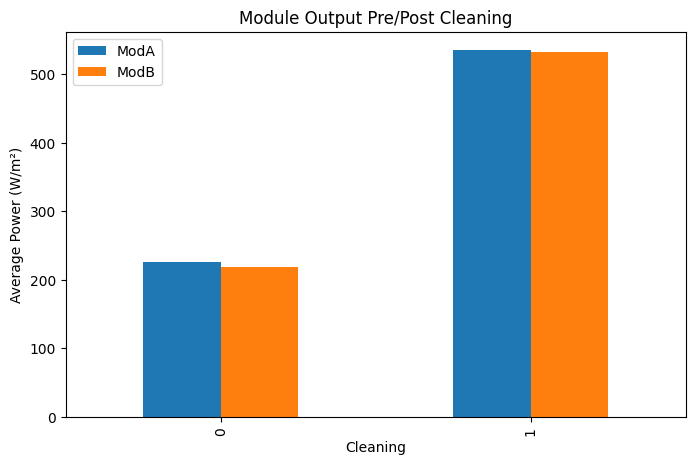

In [28]:
if 'Cleaning' in df_clean.columns:
    df_clean.groupby('Cleaning')[['ModA','ModB']].mean().plot(kind='bar', figsize=(8,5))
    plt.title("Module Output Pre/Post Cleaning")
    plt.ylabel("Average Power (W/m²)")
    plt.show()


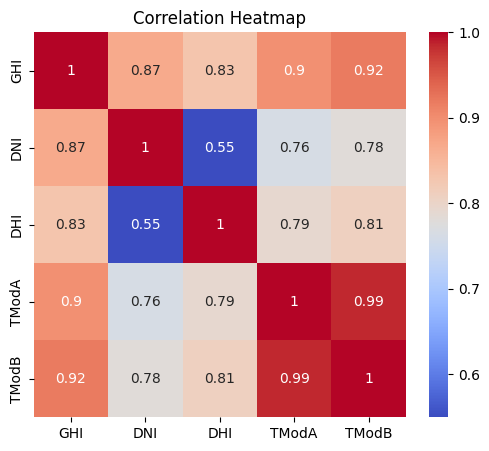

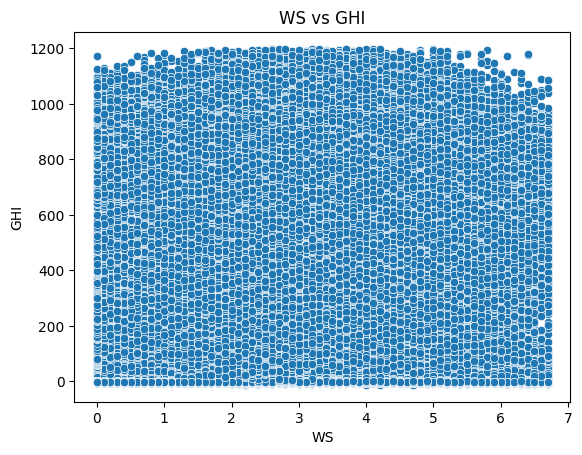

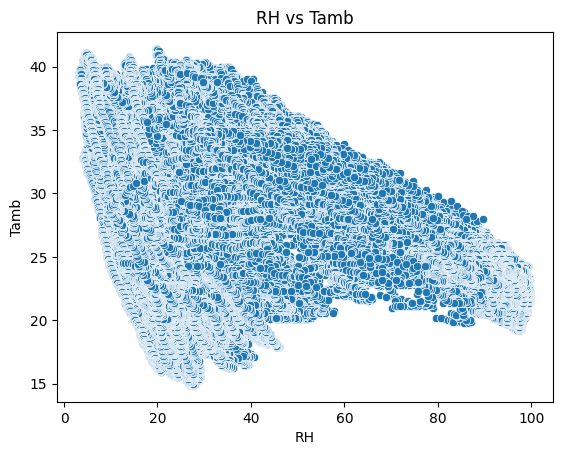

In [29]:
# Correlation heatmap
corr_cols = ['GHI','DNI','DHI','TModA','TModB']
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots
sns.scatterplot(data=df_clean, x='WS', y='GHI')
plt.title("WS vs GHI")
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("RH vs Tamb")
plt.show()


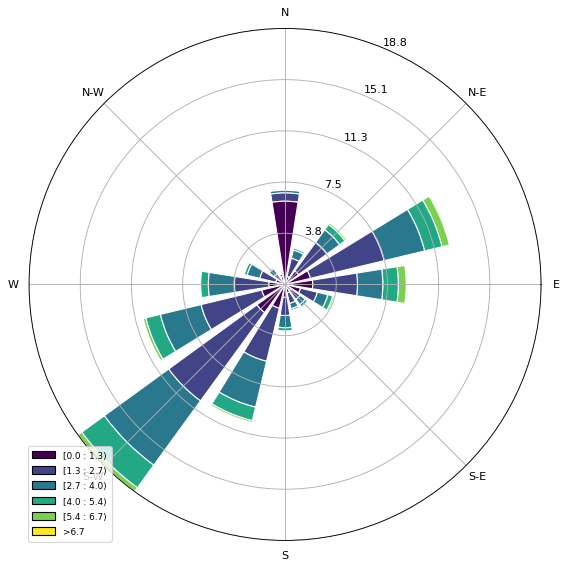

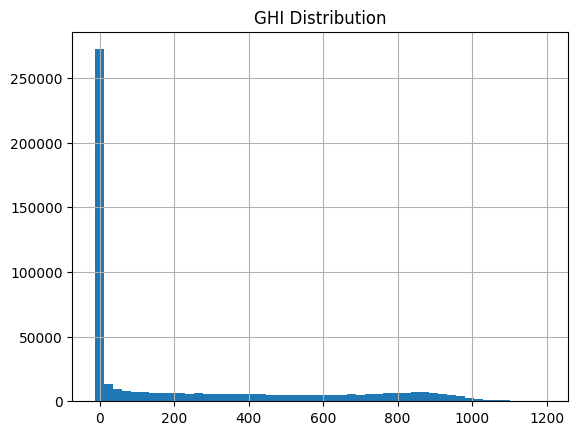

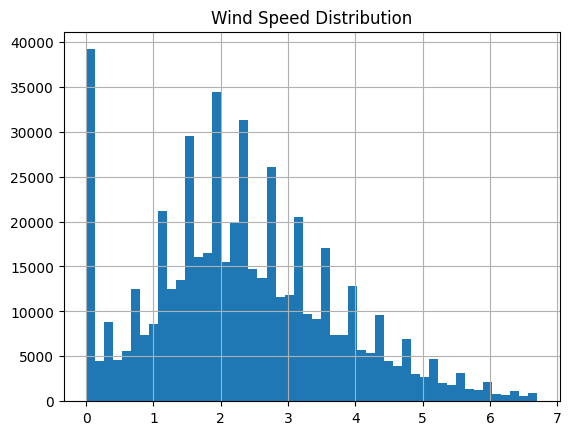

In [30]:
# Wind rose
if 'WD' in df_clean.columns and 'WS' in df_clean.columns:
    ax = WindroseAxes.from_ax()
    ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
    ax.set_legend()
    plt.show()

# Histograms
df_clean['GHI'].hist(bins=50)
plt.title("GHI Distribution")
plt.show()

df_clean['WS'].hist(bins=50)
plt.title("Wind Speed Distribution")
plt.show()


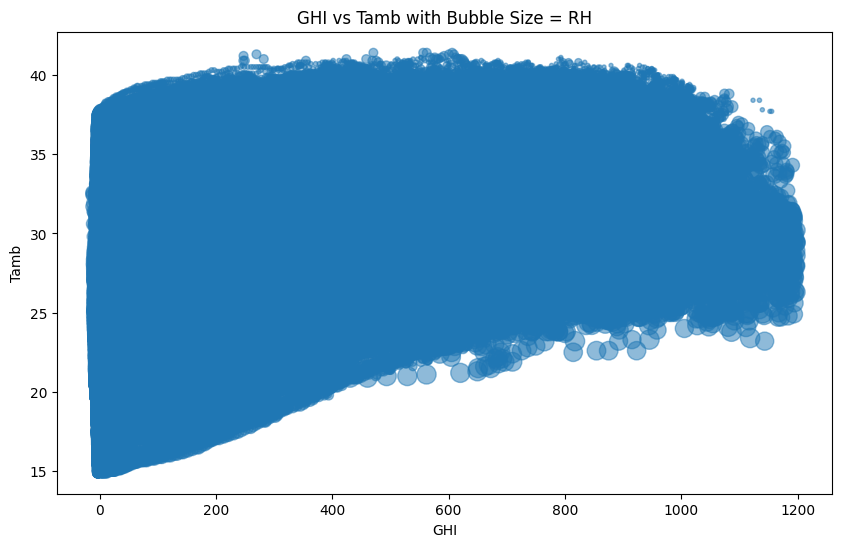

In [31]:
if 'RH' in df_clean.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH']*2, alpha=0.5)
    plt.xlabel('GHI')
    plt.ylabel('Tamb')
    plt.title('GHI vs Tamb with Bubble Size = RH')
    plt.show()
